[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter15_lecture_notebook.ipynb)

# Statistics of Financial Markets — Chapter 15: Systemic risk

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Bank portfolios of the US, Europe and Romania; four systemic episodes (2008, 2011–2012, March 2020, March 2023).
- Correlation and tail dependence in crises; the Forbes–Rigobon correction.
- CoVaR and Delta-CoVaR by quantile regression, static and with state variables.
- MES, LRMES and SRISK; MES before 2008 against the losses in 2008.
- Networks: Granger causality and Diebold–Yilmaz connectedness.
- References: Adrian and Brunnermeier (2016), *American Economic Review*; Acharya, Pedersen, Philippon and Richardson (2017) and Brownlees and Engle (2017), *Review of Financial Studies*; Billio, Getmansky, Lo and Pelizzon (2012); Diebold and Yilmaz (2014); Franke, Härdle and Hafner (2019), *Statistics of Financial Markets*, 5th ed., Ch. 16–17.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_15'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/SFM - Statistica pietelor financiare/2026/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Definitions used in the whole notebook

- Daily log returns $r_t = 100(\ln P_t - \ln P_{t-1})$ in %, computed after joining the prices on common days.
- Banks: 6 US and 5 European banks since 2005, Banca Transilvania (TLV) and BRD since 2010 (BVB days without trades removed; TLV without 30–31 May 2016, a data error). Markets: S&P 500, Euro Stoxx 50, BET.
- Level $\alpha$ = the probability of the tail: VaR 1%, CoVaR 1%, MES 5%; losses are positive numbers.
- CoVaR: quantile regression of the system on the bank at level $\alpha$; $\Delta\mathrm{CoVaR} = \hat b\,(q_{50\%} - q_\alpha)$ of the bank.
- MES: minus the average bank return on the market's worst $\alpha$ of days; SRISK $= kD - (1 - k)(1 - \mathrm{LRMES})W$, $k = 8\%$.

In [5]:
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
from scipy.special import gammaln
START, END = '2005-01-01', '2026-09-18'
BANKS = {'JPM': ('JPM.US', 'JPMorgan Chase', 'US'), 'BAC': ('BAC.US', 'Bank of America', 'US'), 'C': ('C.US', 'Citigroup', 'US'), 'GS': ('GS.US', 'Goldman Sachs', 'US'), 'MS': ('MS.US', 'Morgan Stanley', 'US'), 'WFC': ('WFC.US', 'Wells Fargo', 'US'), 'DBK': ('DBK.XETRA', 'Deutsche Bank', 'EU'), 'BNP': ('BNP.PA', 'BNP Paribas', 'EU'), 'SAN': ('SAN.MC', 'Santander', 'EU'), 'INGA': ('INGA.AS', 'ING', 'EU'), 'HSBA': ('HSBA.LSE', 'HSBC', 'EU'), 'TLV': ('TLV.RO', 'Banca Transilvania', 'RO'), 'BRD': ('BRD.RO', 'BRD', 'RO')}
REGIONS = {'US': ['JPM', 'BAC', 'C', 'GS', 'MS', 'WFC'], 'EU': ['DBK', 'BNP', 'SAN', 'INGA', 'HSBA'], 'RO': ['TLV', 'BRD']}
ALL = ['JPM', 'BAC', 'C', 'GS', 'MS', 'WFC', 'DBK', 'BNP', 'SAN', 'INGA', 'HSBA', 'TLV', 'BRD']
INTL = ['JPM', 'BAC', 'C', 'GS', 'MS', 'WFC', 'DBK', 'BNP', 'SAN', 'INGA', 'HSBA']
REGION_START = {'US': '2005-01-01', 'EU': '2005-01-01', 'RO': '2010-01-01'}
INDEX = {'US': 'sp500', 'EU': 'stoxx50', 'RO': 'bet'}
INDEX_NAME = {'sp500': 'S&P 500', 'stoxx50': 'Euro Stoxx 50', 'bet': 'BET'}
REG_COL = {'US': '#1A3A6E', 'EU': '#CD0000', 'RO': '#2E7D32'}
REG_LAB = {'US': 'US banks', 'EU': 'European banks', 'RO': 'Romanian banks (TLV, BRD, since 2010)'}
BAD_DAYS = {'TLV': ['2016-05-30', '2016-05-31']}
EVENTS = [('2008-09-15', 'Lehman'), ('2012-07-26', 'Draghi'), ('2020-03-16', 'COVID-19'), ('2023-03-10', 'SVB')]
EPISODES = {'Lehman 2008': ('2008-08-29', '2008-12-31'), 'Euro area 2011-2012': ('2011-06-30', '2012-09-28'), 'March 2020': ('2020-02-14', '2020-04-30'), 'March 2023': ('2023-02-28', '2023-04-28')}
ALPHA = 0.01
ALPHA_MES = 0.05
K_CAP = 0.08
B_BOOT, BLOCK = 200, 20
GC_WINDOW = 36
DY_H, DY_WINDOW, DY_STEP = 10, 200, 5
SEED = 2026


def bank_price(k, start=START, end=END):
    """Daily adjusted close of a bank (weekdays; no unchanged holiday-filled closes; BVB: no days without trades)."""
    sym, _, reg = BANKS[k]
    d = read_market(sym).loc[start:end]
    d = d[(d.index.dayofweek < 5) & (d['adjusted_close'] > 0)]
    if reg == 'RO' and 'volume' in d.columns:
        d = d[d['volume'] > 0]
    s = d['adjusted_close'].astype(float)
    return s[s.diff() != 0].rename(k)


def prices(keys, start=START, end=END):
    """Banks and indices (sp500, stoxx50, bet, vix) on their common trading days."""
    cols = [bank_price(k, start, end) if k in BANKS else load_close(k, start, end).rename(k) for k in keys]
    return pd.concat(cols, axis=1, join='inner').dropna()


def returns(keys, start=START, end=END):
    """Daily log returns in %: prices joined on common days first, then returns; known data errors removed."""
    R = 100 * np.log(prices(keys, start, end)).diff().dropna()
    for k, days in BAD_DAYS.items():
        if k in R.columns:
            R = R.drop(pd.to_datetime(days), errors='ignore')
    return R


def region_returns(reg, start=None, end=END):
    """The banks of a region and its equity index (S&P 500, Euro Stoxx 50 or BET), daily log returns in %."""
    return returns(REGIONS[reg] + [INDEX[reg]], max(start or START, REGION_START[reg]), end)


def bank_portfolio(R, members):
    """Equal-weighted bank portfolio (daily rebalancing): log return in % of the average simple return."""
    return 100 * np.log(1 + (np.exp(R[members] / 100) - 1).mean(axis=1))

## 1. Bank portfolios and four crises

- Equal-weighted portfolios with daily rebalancing; cumulative returns in four episodes.

In [6]:
def fig_bank_indices(save=True):
    """Value of 100 invested in each equal-weighted regional bank portfolio in January 2005."""
    fig, ax = plt.subplots(figsize=(11, 3.9))
    out = {}
    for reg in ('US', 'EU', 'RO'):
        R = region_returns(reg)
        p = bank_portfolio(R, REGIONS[reg])
        v = 100 * np.exp(p.cumsum() / 100)
        dd = v / v.cummax() - 1
        ax.plot(v.index, v, color=REG_COL[reg], lw=1.3, label=REG_LAB[reg])
        out[reg] = {'last': float(v.iloc[-1]), 'maxdd': float(100 * dd.min()), 'date_dd': dd.idxmin().date().isoformat(),
                    'peak': float(v.loc[:'2008-12-31'].max()), 'start': R.index[0].date().isoformat(), 'n': len(R)}
    ax.set_yscale('log')
    ax.axhline(100, color=st.Amber, ls='--', lw=1.0, label='starting value 100')
    for d, lab in EVENTS:
        ax.axvline(pd.Timestamp(d), color=st.Purple, ls=':', lw=1.0, label='_')
        ax.text(pd.Timestamp(d), ax.get_ylim()[1], ' ' + lab, rotation=90, va='top', ha='right', fontsize=10, color='black')
    ax.set_ylabel('value of 100 invested in 2005 (log scale)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.13)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch15_bank_indices')
    return out


def episode_paths():
    """Cumulative return (%) of the three bank portfolios and of the S&P 500 in each episode."""
    out = {}
    R = {reg: region_returns(reg) for reg in ('US', 'EU', 'RO')}
    for e, (a, b) in EPISODES.items():
        out[e] = {}
        for reg in ('US', 'EU', 'RO'):
            if pd.Timestamp(a) < pd.Timestamp(REGION_START[reg]):
                continue
            p = bank_portfolio(R[reg], REGIONS[reg]).loc[a:b].iloc[1:]
            out[e][reg] = 100 * (np.exp(p.cumsum() / 100) - 1)
        s = R['US']['sp500'].loc[a:b].iloc[1:]
        out[e]['sp500'] = 100 * (np.exp(s.cumsum() / 100) - 1)
    return out


def fig_episodes(save=True):
    """Four systemic episodes: cumulative return of the bank portfolios and of the S&P 500 from the start date."""
    P = episode_paths()
    fig, axes = plt.subplots(2, 2, figsize=(11.5, 5.6))
    res = {}
    for ax, (e, d) in zip(axes.ravel(), P.items()):
        for reg in ('US', 'EU', 'RO'):
            if reg in d:
                ax.plot(d[reg].index, d[reg], color=REG_COL[reg], lw=1.4, label=REG_LAB[reg])
        ax.plot(d['sp500'].index, d['sp500'], color=st.Amber, lw=1.4, ls='--', label='S&P 500')
        ax.axhline(0, color=st.Purple, lw=0.8, ls=':', label='_')
        ax.set_title(e, fontsize=12)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3 if e.startswith('Euro') else 1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y' if e.startswith('Euro') else '%d %b'))
        ax.tick_params(axis='x', labelsize=10.5)
        res[e] = {k: {'min': float(v.min()), 'date_min': v.idxmin().date().isoformat(), 'end': float(v.iloc[-1])}
                  for k, v in d.items()}
    for ax in axes[:, 0]:
        ax.set_ylabel('cumulative return (%)')
    fig.tight_layout()
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.subplots_adjust(bottom=0.13)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch15_episodes')
    return res

{'US': {'last': 651.2733150879651,
  'maxdd': -82.27726967746534,
  'date_dd': '2009-03-06',
  'peak': 149.07073800067195,
  'start': '2005-01-04',
  'n': 5229},
 'EU': {'last': 468.9203977421945,
  'maxdd': -75.65952310785528,
  'date_dd': '2009-03-09',
  'peak': 164.81288058250308,
  'start': '2005-01-07',
  'n': 5212},
 'RO': {'last': 1194.4141692216572,
  'maxdd': -47.418824987402616,
  'date_dd': '2012-06-05',
  'peak': nan,
  'start': '2010-01-05',
  'n': 3414}}

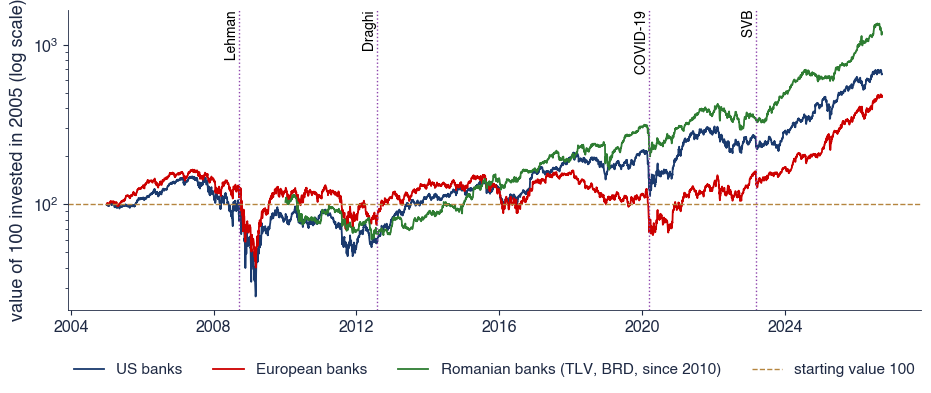

In [7]:
fig_bank_indices(save=False)

{'Lehman 2008': {'US': {'min': -59.38221114514845,
   'date_min': '2008-11-21',
   'end': -38.893155118949366},
  'EU': {'min': -53.99380172869749,
   'date_min': '2008-11-21',
   'end': -44.53702456434726},
  'sp500': {'min': -41.34530686061285,
   'date_min': '2008-11-20',
   'end': -29.5892674789333}},
 'Euro area 2011-2012': {'US': {'min': -36.837741305578895,
   'date_min': '2011-11-23',
   'end': -7.644037624573885},
  'EU': {'min': -41.1504966126765,
   'date_min': '2011-09-22',
   'end': -16.937632848825523},
  'RO': {'min': -34.35949543349637,
   'date_min': '2012-06-05',
   'end': -28.823863048138453},
  'sp500': {'min': -16.76535619093773,
   'date_min': '2011-10-03',
   'end': 9.0887751393264}},
 'March 2020': {'US': {'min': -47.61174412132158,
   'date_min': '2020-03-23',
   'end': -31.298074462795565},
  'EU': {'min': -48.36079564974693,
   'date_min': '2020-04-21',
   'end': -42.126300418365446},
  'RO': {'min': -35.29574636159045,
   'date_min': '2020-03-23',
   'end': 

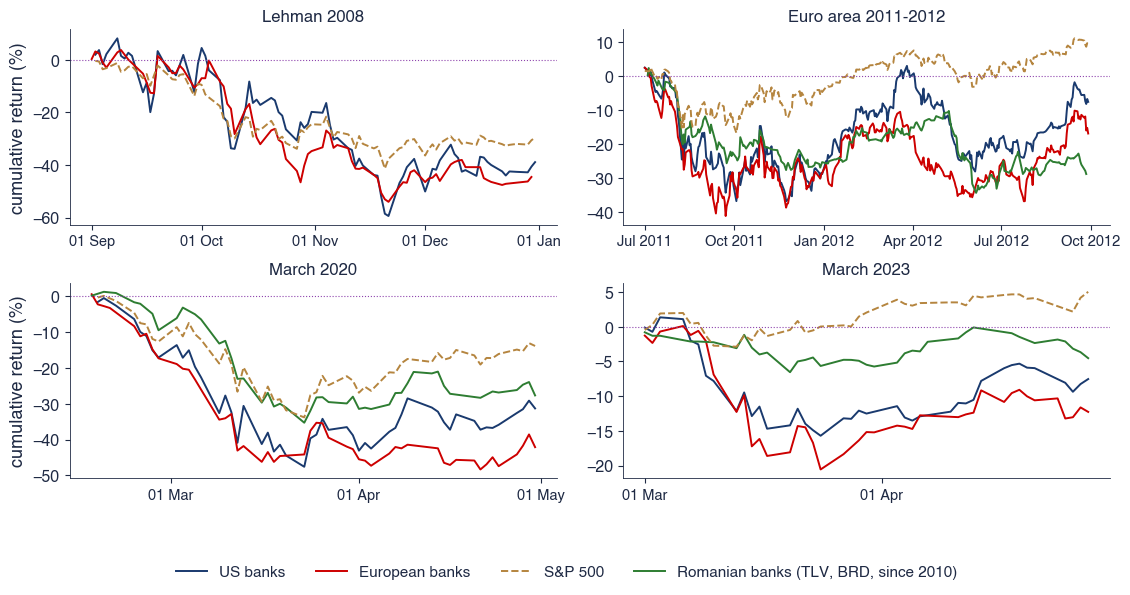

In [8]:
fig_episodes(save=False)

## 2. Correlation and tail dependence in crises

- 120-day average pairwise correlation; the Forbes–Rigobon correction; empirical tail dependence and the t copula.

In [9]:
def pseudo_obs(X):
    """Ranks divided by n + 1 (pseudo-observations, Chapter 10)."""
    X = np.asarray(X, float)
    return stats.rankdata(X, axis=0) / (len(X) + 1)


def empirical_tail_dep(x, y, q=0.05):
    """P(U_x <= q | U_y <= q) from the pseudo-observations."""
    U = pseudo_obs(np.column_stack([x, y]))
    return float(np.mean(U[U[:, 1] <= q, 0] <= q))


def t_copula_fit(x, y):
    """t copula: rho = sin(pi tau / 2) from Kendall's tau, nu by maximum likelihood on a grid (Chapter 10)."""
    U = pseudo_obs(np.column_stack([x, y]))
    tau = stats.kendalltau(x, y)[0]
    rho = np.sin(np.pi * tau / 2)

    def nll(nu):
        z = stats.t.ppf(U, nu)
        q = (z[:, 0] ** 2 - 2 * rho * z[:, 0] * z[:, 1] + z[:, 1] ** 2) / (1 - rho ** 2)
        ll = (gammaln((nu + 2) / 2) - gammaln(nu / 2) - np.log(nu * np.pi) - 0.5 * np.log(1 - rho ** 2)
              - (nu + 2) / 2 * np.log(1 + q / nu) - stats.t.logpdf(z, nu).sum(axis=1))
        return -ll.sum()
    r = optimize.minimize_scalar(nll, bounds=(2.05, 60), method='bounded')
    nu = float(r.x)
    lam = 2 * stats.t.cdf(-np.sqrt((nu + 1) * (1 - rho) / (1 + rho)), nu + 1)
    return {'tau': float(tau), 'rho': float(rho), 'nu': nu, 'lambda': float(lam)}


def avg_pairwise_corr(R, window=120):
    """Rolling average of the pairwise correlations of the columns of R."""
    cols = list(R.columns)
    acc = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            acc.append(R[cols[i]].rolling(window).corr(R[cols[j]]))
    return pd.concat(acc, axis=1).mean(axis=1).dropna()


def forbes_rigobon(rho, delta):
    """Correlation corrected for the rise in volatility (Forbes and Rigobon, 2002): rho / sqrt(1 + delta (1 - rho^2)),
    delta = relative increase in the variance of the source market."""
    return rho / np.sqrt(1 + delta * (1 - rho ** 2))


def fig_rolling_corr(save=True):
    """120-day average pairwise correlation of the bank returns: US banks, European banks, TLV and BRD."""
    fig, ax = plt.subplots(figsize=(11, 3.8))
    out = {}
    for reg in ('US', 'EU', 'RO'):
        R = region_returns(reg)[REGIONS[reg]]
        c = avg_pairwise_corr(R)
        ax.plot(c.index, c, color=REG_COL[reg], lw=1.2, label=REG_LAB[reg])
        out[reg] = {'calm': float(c.loc['2005-07-01':'2007-06-30'].mean()) if reg != 'RO' else None, 'y2017': float(c.loc['2017'].mean()),
                    'max': float(c.max()), 'date_max': c.idxmax().date().isoformat(), 'last': float(c.iloc[-1]),
                    'c2008': float(c.loc['2008-10-01':'2009-03-31'].mean()) if reg != 'RO' else None, 'c2020': float(c.loc['2020-04-01':'2020-06-30'].mean())}
    for d, lab in EVENTS:
        ax.axvline(pd.Timestamp(d), color=st.Purple, ls=':', lw=1.0, label='_')
        ax.text(pd.Timestamp(d), 1.0, ' ' + lab, rotation=90, va='top', ha='right', fontsize=10, color='black')
    ax.set_ylim(-0.05, 1.0)
    ax.set_ylabel('average pairwise correlation\n(120-day window)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.13)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch15_rolling_corr')
    return out


def contagion_test(calm=('2005-01-01', '2007-06-29'), crisis=('2008-09-15', '2008-12-31')):
    """US bank portfolio (source) and European bank portfolio: correlation in a calm and in a crisis period, and the
    Forbes-Rigobon correction with delta from the variance of the source market."""
    R = returns(REGIONS['US'] + REGIONS['EU'])
    us, eu = bank_portfolio(R, REGIONS['US']), bank_portfolio(R, REGIONS['EU'])
    c0 = us.loc[calm[0]:calm[1]].corr(eu.loc[calm[0]:calm[1]])
    c1 = us.loc[crisis[0]:crisis[1]].corr(eu.loc[crisis[0]:crisis[1]])
    v0, v1 = us.loc[calm[0]:calm[1]].var(), us.loc[crisis[0]:crisis[1]].var()
    delta = v1 / v0 - 1
    return {'rho_calm': float(c0), 'rho_crisis': float(c1), 'var_calm': float(v0), 'var_crisis': float(v1),
            'delta': float(delta), 'rho_adj': float(forbes_rigobon(c1, delta)),
            'n_calm': int(len(us.loc[calm[0]:calm[1]])), 'n_crisis': int(len(us.loc[crisis[0]:crisis[1]]))}


def tail_table():
    """Correlation, empirical lower tail dependence (q = 5%, 1%) and the t copula for four pairs."""
    out = {}
    for reg in ('US', 'EU', 'RO'):
        R = region_returns(reg)
        p = bank_portfolio(R, REGIONS[reg])
        m = R[INDEX[reg]]
        out[reg] = {'n': len(R), 'corr': float(np.corrcoef(p, m)[0, 1]), 'td5': empirical_tail_dep(p, m, 0.05),
                    'td1': empirical_tail_dep(p, m, 0.01), **t_copula_fit(p.values, m.values)}
    R = returns(REGIONS['US'] + REGIONS['EU'])
    us, eu = bank_portfolio(R, REGIONS['US']), bank_portfolio(R, REGIONS['EU'])
    out['USEU'] = {'n': len(R), 'corr': float(np.corrcoef(us, eu)[0, 1]), 'td5': empirical_tail_dep(eu, us, 0.05),
                   'td1': empirical_tail_dep(eu, us, 0.01), **t_copula_fit(eu.values, us.values)}
    return out


def fig_tail_scatter(save=True):
    """Pseudo-observations of the bank portfolio against its index (lower-left corner): US and Romania."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
    out = {}
    for ax, reg in zip(axes, ('US', 'RO')):
        R = region_returns(reg)
        U = pseudo_obs(np.column_stack([R[INDEX[reg]], bank_portfolio(R, REGIONS[reg])]))
        both = (U[:, 0] <= 0.05) & (U[:, 1] <= 0.05)
        ax.scatter(U[~both, 0], U[~both, 1], s=6, color=REG_COL[reg], alpha=0.45, label='_')
        ax.scatter(U[both, 0], U[both, 1], s=10, color=st.Orange, label='both in their worst 5% of days')
        ax.plot([0, 0.05, 0.05], [0.05, 0.05, 0], color=st.Amber, lw=1.6, label='_')
        ax.set_xlim(0, 0.3)
        ax.set_ylim(0, 0.3)
        ax.set_xlabel(f'{INDEX_NAME[INDEX[reg]]} (uniform scale)')
        ax.set_title(f'{REG_LAB[reg]}\n{int(both.sum())} joint bad days; {0.05 * 0.05 * len(U):.0f} expected '
                     'under independence', fontsize=11)
        out[reg] = {'both': int(both.sum()), 'exp': float(0.0025 * len(U)), 'n': len(U)}
    axes[0].set_ylabel('bank portfolio (uniform scale)')
    st.fig_legend_bottom(fig, ncol=1, y=0.0)
    fig.subplots_adjust(bottom=0.25)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch15_tail_scatter')
    return out

{'US': {'calm': 0.5943848920680203,
  'y2017': 0.7915427905892211,
  'max': 0.9370664416464343,
  'date_max': '2020-03-16',
  'last': 0.6096447949558925,
  'c2008': 0.7233119417065131,
  'c2020': 0.9176851857855928},
 'EU': {'calm': 0.6402276303235079,
  'y2017': 0.5913396574476301,
  'max': 0.845439516628438,
  'date_max': '2008-09-19',
  'last': 0.7647587813349102,
  'c2008': 0.7124829636219865,
  'c2020': 0.7609136283999194},
 'RO': {'calm': None,
  'y2017': 0.3061192479916268,
  'max': 0.9266735204309152,
  'date_max': '2019-05-09',
  'last': 0.36237337660632135,
  'c2008': None,
  'c2020': 0.8512100034863769}}

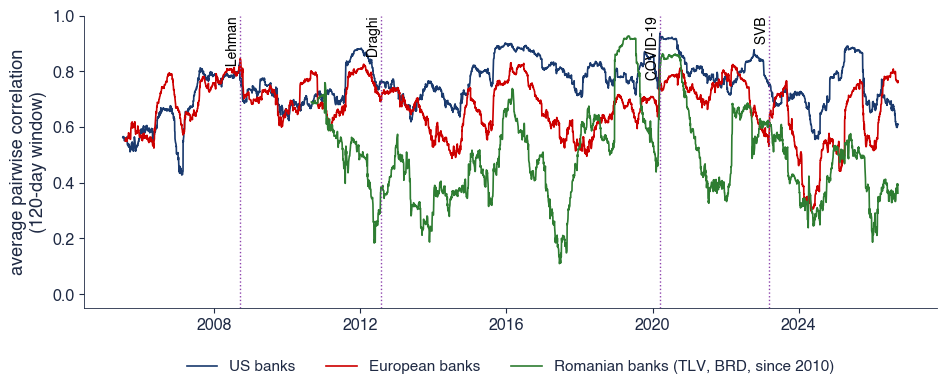

In [10]:
fig_rolling_corr(save=False)

In [11]:
contagion_test()

{'rho_calm': 0.4033614166054101,
 'rho_crisis': 0.601471991491272,
 'var_calm': 0.8903160529749448,
 'var_crisis': 75.38844286247686,
 'delta': 83.67604578236043,
 'rho_adj': 0.08154498638177327,
 'n_calm': 506,
 'n_crisis': 72}

In [12]:
pd.DataFrame(tail_table()).T.round(3)

,n,corr,td5,td1,tau,rho,nu,lambda
US,5229.0,0.788,0.636,0.635,0.556,0.766,3.229,0.494
EU,5212.0,0.863,0.723,0.673,0.641,0.845,3.110,0.588
RO,3414.0,0.861,0.647,0.618,0.640,0.844,4.330,0.530
USEU,4895.0,0.590,0.434,0.500,0.387,0.571,2.989,0.356


{'US': {'both': 166, 'exp': 13.0725, 'n': 5229},
 'RO': {'both': 110, 'exp': 8.535, 'n': 3414}}

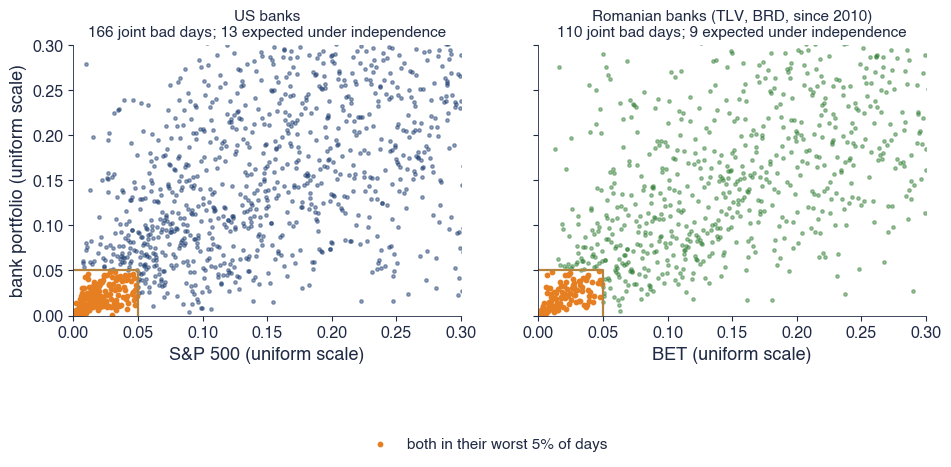

In [13]:
fig_tail_scatter(save=False)

## 3. CoVaR and Delta-CoVaR

- Quantile regression of the regional index on each bank at 1% (and 5%); moving-block bootstrap intervals.

In [14]:
def qreg(y, X, q):
    """Linear quantile regression (Koenker and Bassett, 1978): coefficients [intercept, slopes]."""
    return QuantReg(np.asarray(y), sm.add_constant(np.asarray(X), has_constant='add')).fit(q=q, max_iter=5000).params


def covar(x_sys, x_i, alpha=ALPHA):
    """CoVaR and Delta-CoVaR (%, losses positive): quantile regression x_sys = a + b x_i at level alpha;
    CoVaR = -(a + b q_alpha(x_i)); Delta-CoVaR = b (q_50%(x_i) - q_alpha(x_i))."""
    x_sys, x_i = np.asarray(x_sys, float), np.asarray(x_i, float)
    a, b = qreg(x_sys, x_i, alpha)
    qa, qm = np.quantile(x_i, alpha), np.quantile(x_i, 0.5)
    return {'a': float(a), 'b': float(b), 'q_a': float(qa), 'q_m': float(qm), 'var_i': float(-qa),
            'covar': float(-(a + b * qa)), 'covar_med': float(-(a + b * qm)), 'dcovar': float(b * (qm - qa)),
            'var_sys': float(-np.quantile(x_sys, alpha))}


def block_idx(n, block, rng):
    """Indices of a moving-block bootstrap sample (blocks of `block` consecutive days)."""
    s = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
    return (s[:, None] + np.arange(block)[None, :]).ravel()[:n]


def covar_ci(x_sys, x_i, alpha=ALPHA, B=B_BOOT, block=BLOCK, seed=SEED):
    """95% percentile interval of Delta-CoVaR by moving-block bootstrap."""
    x_sys, x_i = np.asarray(x_sys, float), np.asarray(x_i, float)
    rng = np.random.default_rng(seed)
    d = [covar(x_sys[i], x_i[i], alpha)['dcovar'] for i in (block_idx(len(x_i), block, rng) for _ in range(B))]
    return [float(v) for v in np.percentile(d, [2.5, 97.5])]


def covar_table(boot=True):
    """CoVaR 1% and 5% of the regional index conditional on each bank (2005-2026)."""
    rows = {}
    for reg in ('US', 'EU', 'RO'):
        R = region_returns(reg)
        for k in REGIONS[reg]:
            c1 = covar(R[INDEX[reg]], R[k], 0.01)
            c5 = covar(R[INDEX[reg]], R[k], 0.05)
            rows[k] = {'region': reg, 'n': len(R), **c1, 'dcovar5': c5['dcovar'], 'b5': c5['b'],
                       'ci': covar_ci(R[INDEX[reg]], R[k]) if boot else [np.nan, np.nan]}
    return rows


def fig_covar_qr(save=True):
    """JPMorgan Chase and the S&P 500: quantile regression lines at 1% and 50%, the 1% and median days of JPM."""
    R = region_returns('US')
    x, y = R['JPM'], R['sp500']
    c = covar(y, x, 0.01)
    a50, b50 = qreg(y, x, 0.5)
    fig, ax = plt.subplots(figsize=(10, 4.4))
    ax.scatter(x, y, s=5, color=st.MainBlue, alpha=0.35, label='daily returns, JPMorgan Chase and S&P 500')
    g = np.linspace(x.min(), x.max(), 100)
    ax.plot(g, c['a'] + c['b'] * g, color=st.IDAred, lw=2, label=f'1% quantile regression: {c["a"]:.2f} + {c["b"]:.2f} x')
    ax.plot(g, a50 + b50 * g, color=st.Forest, lw=2, label=f'median regression: {a50:.2f} + {b50:.2f} x')
    ax.axvline(c['q_a'], color=st.Orange, ls='--', lw=1.3, label=f'1% quantile of JPM: {c["q_a"]:.2f}%')
    ax.axvline(c['q_m'], color=st.Purple, ls='--', lw=1.3, label=f'median of JPM: {c["q_m"]:.2f}%')
    ax.plot([c['q_a']], [-c['covar']], 'o', color=st.IDAred, ms=8, label=f'minus CoVaR 1%: {-c["covar"]:.2f}%')
    ax.plot([c['q_m']], [-c['covar_med']], 's', color=st.Forest, ms=8, label=f'minus CoVaR 1% at the median: {-c["covar_med"]:.2f}%')
    ax.set_xlim(-12, 12)
    ax.set_ylim(-13, 8)
    ax.set_xlabel('JPMorgan Chase daily log return (%)')
    ax.set_ylabel('S&P 500 daily log return (%)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch15_covar_qr')
    return {**c, 'a50': float(a50), 'b50': float(b50), 'n': len(R), 'start': R.index[0].date().isoformat()}


def fig_dcovar(t, save=True):
    """Delta-CoVaR 1% of each bank with its 95% block-bootstrap interval."""
    fig, ax = plt.subplots(figsize=(11, 3.9))
    ks = list(t)
    xs = np.arange(len(ks))
    v = np.array([t[k]['dcovar'] for k in ks])
    lo = np.array([t[k]['ci'][0] for k in ks])
    hi = np.array([t[k]['ci'][1] for k in ks])
    ax.bar(xs, v, color=[REG_COL[t[k]['region']] for k in ks], width=0.62)
    ax.errorbar(xs, v, yerr=[v - lo, hi - v], fmt='none', ecolor='black', capsize=3, lw=1)
    ax.set_xticks(xs)
    ax.set_xticklabels([BANKS[k][1] for k in ks], rotation=30, ha='right', fontsize=10.5)
    ax.set_ylabel('Delta-CoVaR 1% (%)')
    h = [plt.Rectangle((0, 0), 1, 1, color=REG_COL[r]) for r in ('US', 'EU', 'RO')]
    lab = ['US banks (system: S&P 500)', 'European banks (system: Euro Stoxx 50)', 'Romanian banks (system: BET)']
    h.append(plt.Line2D([], [], color='black', marker='|', ls='', ms=10))
    lab.append('95% block-bootstrap interval')
    ax.legend(h, lab, loc='upper center', bbox_to_anchor=(0.5, -0.36), ncol=2, frameon=False)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch15_dcovar')


def fig_var_vs_dcovar(t, save=True):
    """VaR 1% of each bank against its Delta-CoVaR 1%."""
    fig, ax = plt.subplots(figsize=(10, 4.2))
    for reg in ('US', 'EU', 'RO'):
        ks = [k for k in t if t[k]['region'] == reg]
        ax.scatter([t[k]['var_i'] for k in ks], [t[k]['dcovar'] for k in ks], s=50, color=REG_COL[reg], label=REG_LAB[reg])
        for k in ks:
            ax.annotate(k, (t[k]['var_i'], t[k]['dcovar']), xytext=(4, 3), textcoords='offset points', fontsize=10, color='black')
    ax.set_xlabel('VaR 1% of the bank (%)')
    ax.set_ylabel('Delta-CoVaR 1% (%)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.17)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch15_var_vs_dcovar')
    rho = stats.spearmanr([t[k]['var_i'] for k in t], [t[k]['dcovar'] for k in t])[0]
    return float(rho)

{'a': -2.346798150895872,
 'b': 0.38982944488855237,
 'q_a': -6.270947988301506,
 'q_m': 0.06693005792053341,
 'var_i': 6.270947988301506,
 'covar': 4.791398324100433,
 'covar_med': 2.3207068435703517,
 'dcovar': 2.4706914805300806,
 'var_sys': 3.533503810907991,
 'a50': 0.0420898632195455,
 'b50': 0.39811790608074127,
 'n': 5229,
 'start': '2005-01-04'}

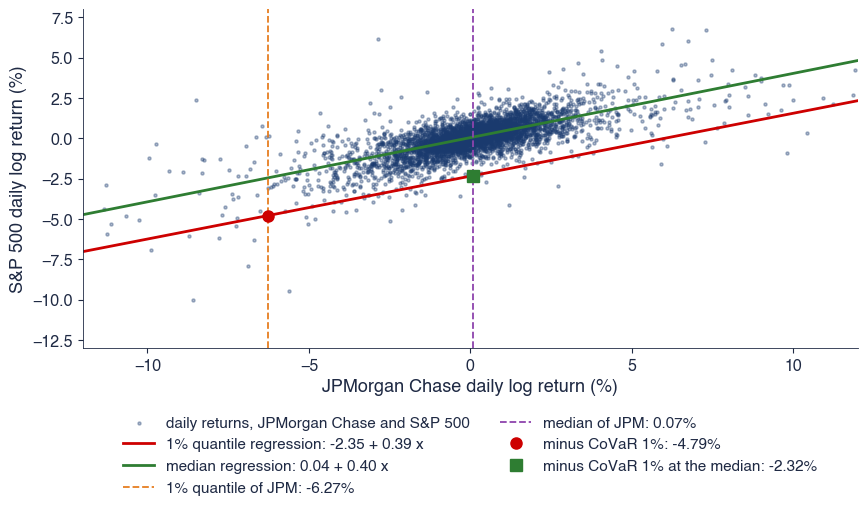

In [15]:
fig_covar_qr(save=False)

In [16]:
CT = covar_table()
pd.DataFrame(CT).T[['region', 'b', 'var_i', 'covar', 'dcovar', 'dcovar5', 'ci']]

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (5000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


,region,b,var_i,covar,dcovar,dcovar5,ci
JPM,US,0.389829,6.270948,4.791398,2.470691,1.220324,"[1.8012234195682455, 3.1054174711209312]"
BAC,US,0.262806,8.132575,4.788285,2.153733,1.120121,"[1.6811913511663281, 2.7669450982196646]"
C,US,0.252147,8.21635,4.566901,2.081463,1.175637,"[1.5387470281028761, 2.7990506407243054]"
GS,US,0.414073,5.875134,4.838907,2.463305,1.327147,"[1.9868592559093465, 3.410271201790363]"
MS,US,0.312792,7.968045,4.821723,2.520911,1.208773,"[1.7950519661718327, 3.2395402899212318]"
WFC,US,0.337866,6.886394,4.872014,2.340505,1.162913,"[1.6655499757849042, 2.956785436723491]"
DBK,EU,0.381583,7.575451,5.279334,2.903426,1.560683,"[2.2446436470675137, 3.8279558809708765]"
BNP,EU,0.454254,6.821087,5.395202,3.13269,1.648248,"[2.477942940734145, 3.670228667550946]"
SAN,EU,0.505945,6.036288,5.35717,3.094556,1.676985,"[2.3577158880782205, 3.8238613741778646]"
INGA,EU,0.37045,8.522748,5.375454,3.184101,1.564125,"[2.249552943859155, 3.9033571688904756]"


-0.30769230769230765

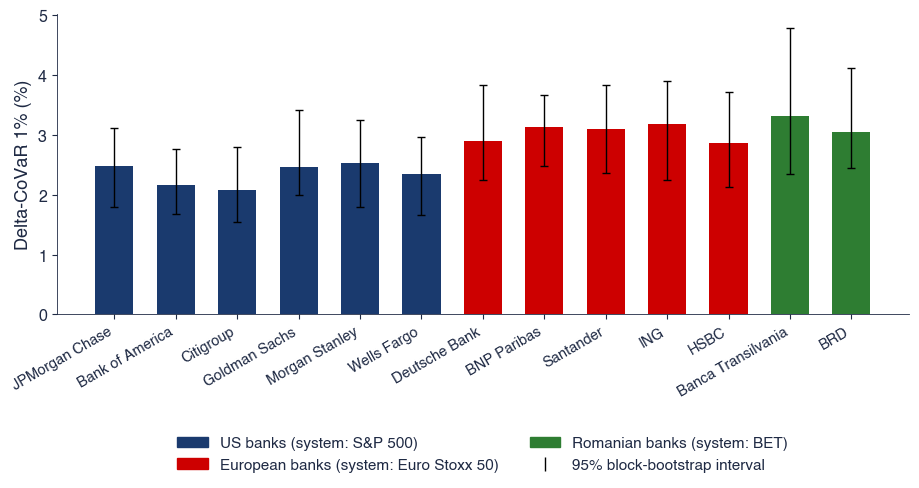

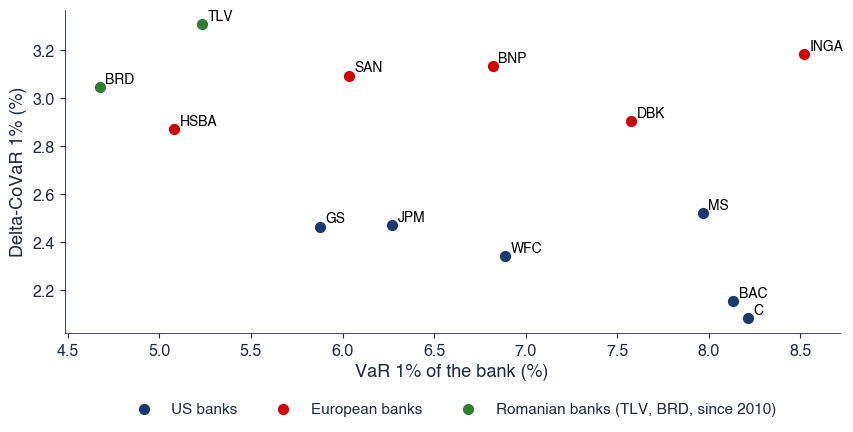

In [17]:
fig_dcovar(CT, save=False)
fig_var_vs_dcovar(CT, save=False)

## 4. Time-varying Delta-CoVaR

- State variables: the VIX level and the index return of the previous day.

In [18]:
def dynamic_dcovar(k, alpha=ALPHA):
    """Time-varying Delta-CoVaR (Adrian and Brunnermeier, 2016, Section II) with the lagged state variables
    M_{t-1} = (VIX level, index return): quantile regressions x_i = c + g'M (levels alpha and 50%) and
    x_sys = a + b x_i + g'M (level alpha); Delta-CoVaR_t = b (q50_t - qalpha_t)."""
    reg = BANKS[k][2]
    R = region_returns(reg)
    vix = load_close('vix', START, END)
    D = pd.concat([R[[k, INDEX[reg]]], vix.reindex(R.index).ffill().rename('vix')], axis=1).dropna()
    M = pd.concat([D['vix'].shift(1), D[INDEX[reg]].shift(1)], axis=1).iloc[1:]
    D = D.iloc[1:]
    ca, cm = qreg(D[k], M, alpha), qreg(D[k], M, 0.5)
    cs = qreg(D[INDEX[reg]], np.column_stack([D[k], M]), alpha)
    Mc = sm.add_constant(M.values, has_constant='add')
    qa, qm = Mc @ ca, Mc @ cm
    return pd.Series(cs[1] * (qm - qa), index=D.index, name=k), float(cs[1])


def fig_dcovar_dynamic(save=True):
    """Time-varying Delta-CoVaR 1% of JPMorgan Chase, Deutsche Bank and Banca Transilvania."""
    fig, ax = plt.subplots(figsize=(11, 3.8))
    out = {}
    for k, c in [('JPM', REG_COL['US']), ('DBK', REG_COL['EU']), ('TLV', REG_COL['RO'])]:
        s, b = dynamic_dcovar(k)
        ax.plot(s.index, s, color=c, lw=0.9, label=f'{BANKS[k][1]}')
        out[k] = {'mean': float(s.mean()), 'max': float(s.max()), 'date_max': s.idxmax().date().isoformat(),
                  'b': b, 'y2017': float(s.loc['2017'].mean()), 'last': float(s.iloc[-1])}
    for d, lab in EVENTS:
        ax.axvline(pd.Timestamp(d), color=st.Purple, ls=':', lw=1.0, label='_')
    ax.set_ylabel('Delta-CoVaR 1% (%)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.13)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch15_dcovar_dynamic')
    return out

{'JPM': {'mean': 1.8630565708711415,
  'max': 10.073691969622182,
  'date_max': '2020-03-18',
  'b': 0.36523125296647474,
  'y2017': 0.7512608582834809,
  'last': 1.4230677939731224},
 'DBK': {'mean': 2.322223708419871,
  'max': 9.077215083720407,
  'date_max': '2020-03-13',
  'b': 0.36830493746084225,
  'y2017': 1.5510848614258008,
  'last': 1.8697104863807839},
 'TLV': {'mean': 2.448792730796653,
  'max': 12.810574230781542,
  'date_max': '2020-03-17',
  'b': 0.5085901006806356,
  'y2017': 1.5638207945802618,
  'last': 3.1865751773860786}}

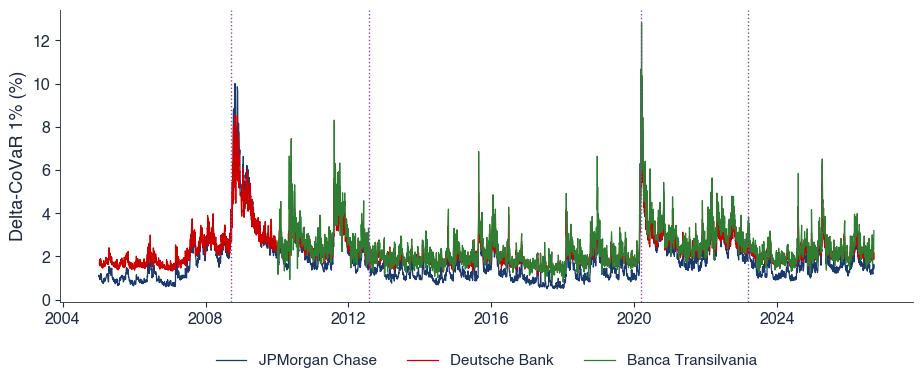

In [19]:
fig_dcovar_dynamic(save=False)

## 5. MES, LRMES and SRISK

- MES 5% with bootstrap intervals; LRMES $= 1 - \exp(-18\,\mathrm{MES}_{2\%})$; SRISK as a function of leverage; MES from June 2006 to June 2007 against the returns from July 2007 to December 2008.

In [20]:
def mes(x_i, x_m, alpha=ALPHA_MES):
    """MES (%): minus the average return of the bank on the market's worst alpha of days."""
    x_i, x_m = np.asarray(x_i, float), np.asarray(x_m, float)
    return float(-x_i[x_m <= np.quantile(x_m, alpha)].mean())


def mes_threshold(x_i, x_m, c=-2.0):
    """MES (%) on the days when the market falls by more than |c|% (the input of LRMES)."""
    x_i, x_m = np.asarray(x_i, float), np.asarray(x_m, float)
    return float(-x_i[x_m < c].mean())


def lrmes(mes2):
    """Long-run MES, the loss of the bank if the market falls 40% in six months: 1 - exp(-18 MES), MES in %."""
    return float(1 - np.exp(-18 * mes2 / 100))


def srisk(debt, equity, lrm, k=K_CAP):
    """SRISK = k D - (1 - k)(1 - LRMES) W: the capital shortfall in a crisis (positive = missing capital)."""
    return k * debt - (1 - k) * (1 - lrm) * equity


def srisk_ratio(lrm, leverage, k=K_CAP):
    """SRISK / W with leverage L = (D + W) / W: k (L - 1) - (1 - k)(1 - LRMES)."""
    return k * (np.asarray(leverage) - 1) - (1 - k) * (1 - lrm)


def breakeven_leverage(lrm, k=K_CAP):
    """Leverage above which SRISK > 0: L* = 1 + (1 - k)(1 - LRMES) / k."""
    return float(1 + (1 - k) * (1 - lrm) / k)


def mes_table(B=999, seed=SEED):
    """MES 5% with a moving-block bootstrap interval, MES at the -2% threshold, LRMES and the break-even leverage."""
    rng = np.random.default_rng(seed)
    rows = {}
    for reg in ('US', 'EU', 'RO'):
        R = region_returns(reg)
        m = R[INDEX[reg]].values
        for k in REGIONS[reg]:
            x = R[k].values
            boot = [mes(x[i], m[i]) for i in (block_idx(len(x), BLOCK, rng) for _ in range(B))]
            m2 = mes_threshold(x, m)
            beta = float(np.cov(x, m)[0, 1] / np.var(m, ddof=1))
            rows[k] = {'region': reg, 'mes5': mes(x, m), 'lo': float(np.percentile(boot, 2.5)),
                       'hi': float(np.percentile(boot, 97.5)), 'mes2': m2, 'n2': int((m < -2).sum()),
                       'lrmes': lrmes(m2), 'Lstar': breakeven_leverage(lrmes(m2)), 'beta': beta,
                       'es5_m': float(-m[m <= np.quantile(m, 0.05)].mean()), 'n': len(x)}
    return rows


def fig_mes(t, save=True):
    """MES 5% of each bank with its 95% block-bootstrap interval."""
    fig, ax = plt.subplots(figsize=(11, 3.9))
    ks = list(t)
    xs = np.arange(len(ks))
    v = np.array([t[k]['mes5'] for k in ks])
    ax.bar(xs, v, color=[REG_COL[t[k]['region']] for k in ks], width=0.62)
    ax.errorbar(xs, v, yerr=[v - np.array([t[k]['lo'] for k in ks]), np.array([t[k]['hi'] for k in ks]) - v],
                fmt='none', ecolor='black', capsize=3, lw=1)
    ax.set_xticks(xs)
    ax.set_xticklabels([BANKS[k][1] for k in ks], rotation=30, ha='right', fontsize=10.5)
    ax.set_ylabel('MES 5% (daily loss, %)')
    h = [plt.Rectangle((0, 0), 1, 1, color=REG_COL[r]) for r in ('US', 'EU', 'RO')]
    lab = ['US banks (market: S&P 500)', 'European banks (market: Euro Stoxx 50)', 'Romanian banks (market: BET)']
    h.append(plt.Line2D([], [], color='black', marker='|', ls='', ms=10))
    lab.append('95% block-bootstrap interval')
    ax.legend(h, lab, loc='upper center', bbox_to_anchor=(0.5, -0.36), ncol=2, frameon=False)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch15_mes')


def fig_srisk(t, save=True):
    """SRISK per unit of market equity as a function of leverage, for the banks with the largest, median and smallest
    LRMES."""
    order = sorted(t, key=lambda k: t[k]['lrmes'])
    pick = [order[-1], order[len(order) // 2], order[0]]
    L = np.linspace(1, 25, 200)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    for k, c in zip(pick, [st.IDAred, st.Amber, st.MainBlue]):
        lr = t[k]['lrmes']
        ax.plot(L, 100 * srisk_ratio(lr, L), color=c, lw=1.8,
                label=f'{BANKS[k][1]}: LRMES {100 * lr:.0f}%, break-even leverage {t[k]["Lstar"]:.1f}')
        ax.plot(t[k]['Lstar'], 0, 'o', color=c, ms=7, label='_')
    ax.axhline(0, color=st.Purple, lw=1.0, ls=':', label='SRISK = 0')
    ax.set_xlabel('leverage L = (debt + market value of equity) / market value of equity')
    ax.set_ylabel('SRISK / market value of equity (%)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.17)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch15_srisk')
    return pick


def mes_vs_crisis(pre=('2006-06-01', '2007-06-30'), crisis=('2007-07-01', '2008-12-31'), alpha=ALPHA_MES):
    """MES measured before a crisis against the realised (buy-and-hold) return of the bank in the crisis
    (the design of Acharya et al., 2017: MES from June 2006 to June 2007, returns from July 2007 to December 2008)."""
    out = {}
    for reg in ('US', 'EU'):
        R = region_returns(reg, start=pre[0], end=crisis[1])
        P = prices(REGIONS[reg], start=pre[0], end=crisis[1])
        a = R.loc[pre[0]:pre[1]]
        for k in REGIONS[reg]:
            p = P[k].loc[crisis[0]:crisis[1]]
            p0 = P[k].loc[:pre[1]].iloc[-1]
            out[k] = {'region': reg, 'mes': mes(a[k], a[INDEX[reg]], alpha), 'ret': float(100 * (p.iloc[-1] / p0 - 1)),
                      'n_pre': len(a)}
    xs = [out[k]['mes'] for k in out]
    ys = [out[k]['ret'] for k in out]
    sp = stats.spearmanr(xs, ys)
    return out, {'spearman': float(sp[0]), 'p': float(sp[1]), 'n': len(out)}


def fig_mes_crisis(res=None, save=True, name='sfm_ch15_mes_crisis', title=None):
    """Scatter: MES 5% before the crisis against the realised return in the crisis."""
    out, s = mes_vs_crisis() if res is None else res
    fig, ax = plt.subplots(figsize=(10, 4.0))
    for reg in ('US', 'EU', 'RO'):
        ks = [k for k in out if out[k]['region'] == reg]
        if not ks:
            continue
        ax.scatter([out[k]['mes'] for k in ks], [out[k]['ret'] for k in ks], s=55, color=REG_COL[reg], label=REG_LAB[reg])
        for k in ks:
            ax.annotate(k, (out[k]['mes'], out[k]['ret']), xytext=(4, 3), textcoords='offset points', fontsize=10, color='black')
    x = np.array([out[k]['mes'] for k in out])
    y = np.array([out[k]['ret'] for k in out])
    b, a = np.polyfit(x, y, 1)
    g = np.linspace(x.min(), x.max(), 10)
    ax.plot(g, a + b * g, color=st.Orange, lw=1.5, ls='--', label=f'least-squares line; Spearman correlation {s["spearman"]:.2f}')
    ax.set_xlabel('MES 5% before the crisis (%)')
    ax.set_ylabel('return in the crisis (%)')
    if title:
        ax.set_title(title, fontsize=11)
    st.legend_outside_bottom(ax, ncol=2, y=-0.17)
    st.check_no_grey(fig)
    if save:
        st.save_fig(name)
    return s

In [21]:
MT = mes_table()
pd.DataFrame(MT).T.round(3)

,region,mes5,lo,hi,mes2,n2,lrmes,Lstar,beta,es5_m,n
JPM,US,4.196676,3.461283,5.016529,4.474385,222,0.553086,6.13951,1.356882,3.035235,5229
BAC,US,5.312996,4.201822,6.51883,5.684972,222,0.640591,5.133201,1.607706,3.035235,5229
C,US,5.443504,4.311279,6.729144,5.903706,222,0.654467,4.97363,1.658747,3.035235,5229
GS,US,4.047777,3.368374,4.753282,4.329714,222,0.541295,6.275104,1.335244,3.035235,5229
MS,US,5.190776,4.194439,6.338437,5.566146,222,0.632821,5.222557,1.726454,3.035235,5229
WFC,US,4.398206,3.54225,5.211515,4.649138,222,0.566925,5.98036,1.38948,3.035235,5229
DBK,EU,4.8123,4.119108,5.488935,4.735696,274,0.57362,5.903365,1.439659,3.282376,5212
BNP,EU,4.604981,3.96428,5.237139,4.497709,274,0.554958,6.117978,1.37074,3.282376,5212
SAN,EU,4.35237,3.778005,4.967006,4.252438,274,0.53487,6.348992,1.32821,3.282376,5212
INGA,EU,5.350695,4.438537,6.379692,5.230344,274,0.609943,5.485658,1.54188,3.282376,5212


['C', 'BNP', 'HSBA']

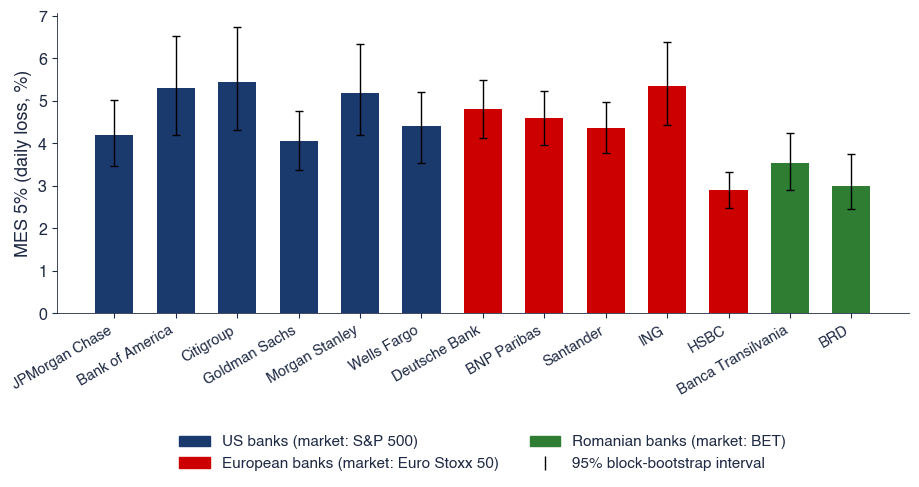

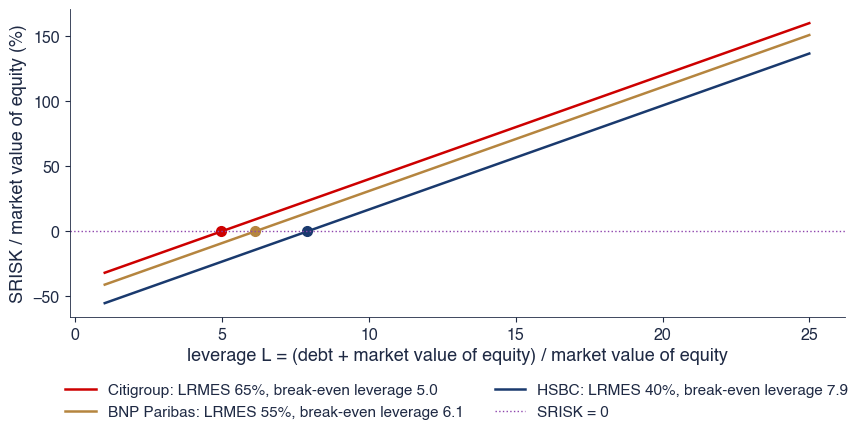

In [22]:
fig_mes(MT, save=False)
fig_srisk(MT, save=False)

{'spearman': -0.39090909090909093, 'p': 0.23454006709519432, 'n': 11}

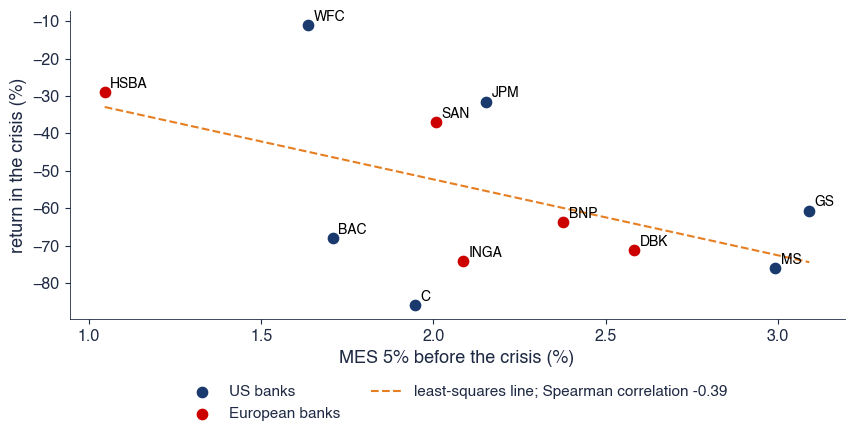

In [23]:
fig_mes_crisis(save=False)

## 6. Networks

- Granger causality on monthly returns, 36-month windows, the degree of Granger causality (DGC).
- Diebold–Yilmaz connectedness of daily returns: the table and the total on 200-day windows.

In [24]:
def monthly_returns():
    """Monthly log returns in % of the 11 US and European banks (last common trading day of each month)."""
    P = prices(INTL)
    Pm = P.groupby(P.index.to_period('M')).last()
    return (100 * np.log(Pm).diff()).dropna()


def granger_p(y, x):
    """p-value of the test that x does not Granger-cause y: regression y_t = a + b y_{t-1} + c x_{t-1} + e_t, t test of c."""
    Y = y[1:]
    X = sm.add_constant(np.column_stack([y[:-1], x[:-1]]))
    return float(sm.OLS(Y, X).fit().pvalues[2])


def granger_network(Rm, level=0.05):
    """Matrix of significant Granger-causal links (row i causes column j) and the degree of Granger causality (DGC)."""
    ks = list(Rm.columns)
    A = np.zeros((len(ks), len(ks)), int)
    for i, a in enumerate(ks):
        for j, b in enumerate(ks):
            if i != j:
                A[i, j] = int(granger_p(Rm[b].values, Rm[a].values) < level)
    n = len(ks)
    return A, float(A.sum() / (n * (n - 1)))


def rolling_dgc(Rm=None, window=GC_WINDOW):
    """DGC on rolling windows of 36 months."""
    Rm = monthly_returns() if Rm is None else Rm
    out = {}
    for e in range(window, len(Rm) + 1):
        out[Rm.index[e - 1].to_timestamp('M')] = granger_network(Rm.iloc[e - window:e])[1]
    return pd.Series(out)


def fig_dgc(save=True):
    """Degree of Granger causality among the 11 US and European banks, 36-month windows; 5% line = links expected by chance."""
    Rm = monthly_returns()
    d = rolling_dgc(Rm)
    fig, ax = plt.subplots(figsize=(11, 3.6))
    ax.plot(d.index, 100 * d, color=st.MainBlue, lw=1.5, label='degree of Granger causality (DGC), 36-month windows')
    ax.axhline(5, color=st.IDAred, ls='--', lw=1.2, label='5%: share of links expected by chance at the 5% level')
    for dd, lab in EVENTS:
        ax.axvline(pd.Timestamp(dd), color=st.Purple, ls=':', lw=1.0, label='_')
        ax.text(pd.Timestamp(dd), ax.get_ylim()[1], ' ' + lab, rotation=90, va='top', ha='right', fontsize=10, color='black')
    ax.set_ylabel('significant links (%)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.13)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch15_dgc')
    return {'first': d.index[0].date().isoformat(), 'max': float(100 * d.max()), 'date_max': d.idxmax().date().isoformat(),
            'min': float(100 * d.min()), 'date_min': d.idxmin().date().isoformat(), 'mean': float(100 * d.mean()),
            'last': float(100 * d.iloc[-1]), 'n_months': len(Rm), 'start': str(Rm.index[0]),
            'd2009': float(100 * d.loc['2009-12-31']), 'd2019': float(100 * d.loc['2019-12-31'])}


def fig_granger_net(ends=('2009-12', '2019-12'), save=True):
    """The Granger-causality network of the 11 US and European banks in two 36-month windows (arrows: significant links at 5%)."""
    Rm = monthly_returns()
    ks = list(Rm.columns)
    ang = np.pi / 2 - 2 * np.pi * np.arange(len(ks)) / len(ks)
    pos = np.column_stack([np.cos(ang), np.sin(ang)])
    fig, axes = plt.subplots(1, 2, figsize=(11, 5.0))
    out = {}
    for ax, e in zip(axes, ends):
        j = list(Rm.index.astype(str)).index(e) + 1
        A, dgc = granger_network(Rm.iloc[j - GC_WINDOW:j])
        for a in range(len(ks)):
            for b in range(len(ks)):
                if A[a, b]:
                    ax.annotate('', xy=pos[b] * 0.9, xytext=pos[a] * 0.9,
                                arrowprops=dict(arrowstyle='->', color=REG_COL[BANKS[ks[a]][2]], lw=0.9, alpha=0.8))
        for i, k in enumerate(ks):
            ax.scatter(*pos[i], s=380, color=REG_COL[BANKS[k][2]], zorder=3)
            ax.text(*(pos[i] * 1.22), k, ha='center', va='center', fontsize=10, color='black')
        a0 = Rm.index[j - GC_WINDOW].strftime('%b %Y')
        ax.set_title(f'{a0} – {Rm.index[j - 1].strftime("%b %Y")}: {A.sum()} links, DGC {100 * dgc:.0f}%', fontsize=11)
        ax.set_xlim(-1.35, 1.35)
        ax.set_ylim(-1.35, 1.35)
        ax.set_aspect('equal')
        ax.axis('off')
        out[e] = {'links': int(A.sum()), 'dgc': float(100 * dgc), 'out': {k: int(A[i].sum()) for i, k in enumerate(ks)}}
    h = [plt.Line2D([], [], color=REG_COL[r], marker='o', ls='-', ms=9) for r in ('US', 'EU')]
    fig.legend(h, [REG_LAB[r] + ' (arrows: links from this bank)' for r in ('US', 'EU')], loc='upper center',
               bbox_to_anchor=(0.5, 0.06), ncol=2, frameon=False)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch15_granger_net')
    return out

{'first': '2008-01-31',
 'max': 39.09090909090909,
 'date_max': '2008-12-31',
 'min': 0.0,
 'date_min': '2020-12-31',
 'mean': 9.648484848484848,
 'last': 10.0,
 'n_months': 260,
 'start': '2005-02',
 'd2009': 23.636363636363637,
 'd2019': 4.545454545454546}

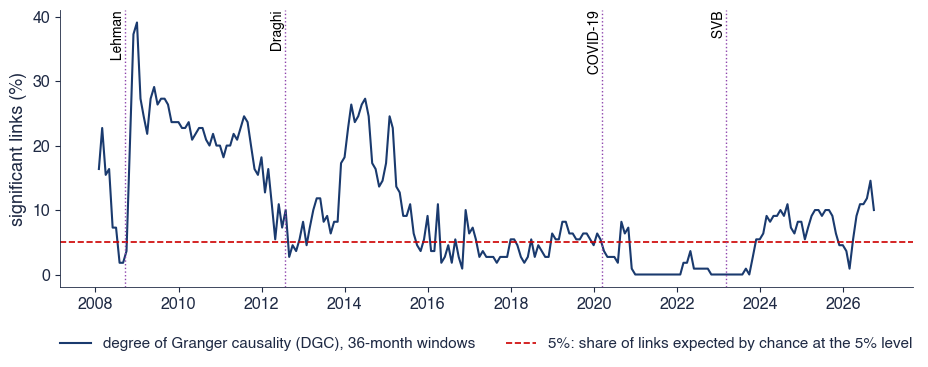

In [25]:
fig_dgc(save=False)

{'2009-12': {'links': 26,
  'dgc': 23.636363636363637,
  'out': {'JPM': 1,
   'BAC': 5,
   'C': 1,
   'GS': 5,
   'MS': 0,
   'WFC': 2,
   'DBK': 7,
   'BNP': 1,
   'SAN': 2,
   'INGA': 1,
   'HSBA': 1}},
 '2019-12': {'links': 5,
  'dgc': 4.545454545454546,
  'out': {'JPM': 2,
   'BAC': 1,
   'C': 0,
   'GS': 1,
   'MS': 0,
   'WFC': 1,
   'DBK': 0,
   'BNP': 0,
   'SAN': 0,
   'INGA': 0,
   'HSBA': 0}}}

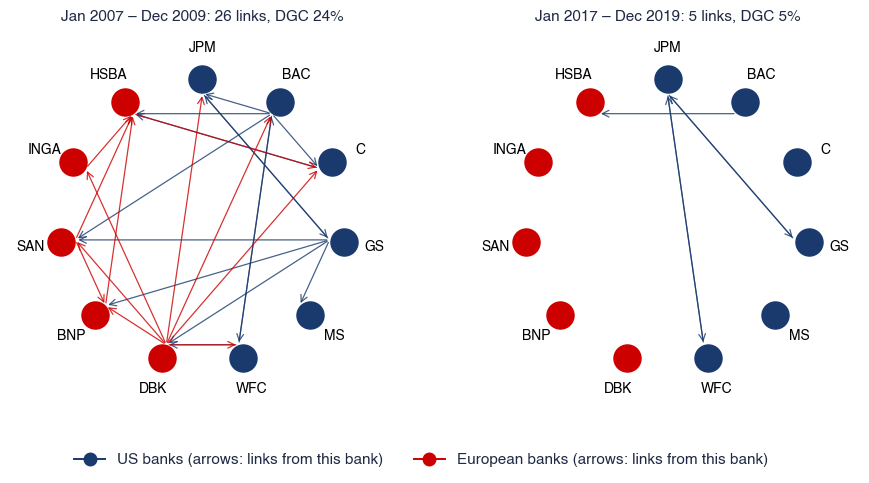

In [26]:
fig_granger_net(save=False)

In [27]:
def var_fit(Y, p):
    """VAR(p) by OLS: lag matrices A_1..A_p and the residual covariance matrix."""
    Y = np.asarray(Y, float)
    T, k = Y.shape
    X = np.hstack([np.ones((T - p, 1))] + [Y[p - l - 1:T - l - 1] for l in range(p)])
    B = np.linalg.lstsq(X, Y[p:], rcond=None)[0]
    E = Y[p:] - X @ B
    S = E.T @ E / (len(E) - X.shape[1])
    return [B[1 + l * k:1 + (l + 1) * k].T for l in range(p)], S


def var_bic(Y, pmax=4):
    """VAR order by the Bayesian information criterion."""
    Y = np.asarray(Y, float)
    T, k = Y.shape
    n = T - pmax
    best = None
    for p in range(1, pmax + 1):
        A, S = var_fit(Y[pmax - p:], p)
        bic = np.log(np.linalg.det(S * (n - 1 - p * k) / n)) + np.log(n) * p * k * k / n
        if best is None or bic < best[1]:
            best = (p, bic)
    return best[0]


def gfevd(A, S, H=DY_H):
    """Generalized forecast error variance decomposition (Pesaran and Shin, 1998), rows normalised to 1."""
    k = S.shape[0]
    Phi = [np.eye(k)]
    for h in range(1, H):
        Phi.append(sum(A[l] @ Phi[h - l - 1] for l in range(min(h, len(A)))))
    num, den = np.zeros((k, k)), np.zeros(k)
    for P in Phi:
        num += (P @ S) ** 2
        den += np.diag(P @ S @ P.T)
    th = num / np.diag(S)[None, :] / den[:, None]
    return th / th.sum(axis=1, keepdims=True)


def connectedness(theta, names):
    """Diebold-Yilmaz table: shares in %, FROM others, TO others, NET and the total connectedness index."""
    D = 100 * theta
    off = D - np.diag(np.diag(D))
    frm, to = off.sum(axis=1), off.sum(axis=0)
    return {'table': pd.DataFrame(D, index=names, columns=names), 'from': pd.Series(frm, index=names),
            'to': pd.Series(to, index=names), 'net': pd.Series(to - frm, index=names), 'total': float(off.sum() / len(names))}


def dy_static():
    """Connectedness of the daily returns of the 11 US and European banks (common days since 2005)."""
    R = returns(INTL)
    p = var_bic(R.values)
    A, S = var_fit(R.values, p)
    c = connectedness(gfevd(A, S), list(R.columns))
    return c, p, len(R)


def fig_dy_table(c, save=True):
    """Heat map of the connectedness table (shares of forecast error variance, %); last row: TO others."""
    T = c['table']
    ks = list(T.index)
    M = np.vstack([T.values, c['to'].values])
    fig, ax = plt.subplots(figsize=(9.5, 6.2))
    ax.imshow(np.vstack([T.values, np.full(len(ks), np.nan)]), cmap='Blues', vmin=0, vmax=np.ceil(T.values.max() / 10) * 10)
    ax.set_xticks(range(len(ks)))
    ax.set_xticklabels(ks, fontsize=10.5)
    ax.xaxis.tick_top()
    ax.set_yticks(range(len(ks) + 1))
    ax.set_yticklabels([f'{k}  (FROM {c["from"][k]:.0f})' for k in ks] + ['TO others'], fontsize=10.5)
    for i in range(len(ks) + 1):
        for j in range(len(ks)):
            v = M[i, j]
            col = st.IDAred if i == len(ks) else ('white' if v > 0.55 * T.values.max() else 'black')
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=9.5, color=col)
    ax.set_xlabel(f'shock from (column) to (row), % of the forecast error variance\ntotal connectedness {c["total"]:.1f}%',
                  fontsize=11)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch15_dy_table')


def rolling_total(R=None, window=DY_WINDOW, step=DY_STEP, p=None):
    """Total connectedness on rolling windows of 200 days, moved by 5 days."""
    R = returns(INTL) if R is None else R
    p = var_bic(R.values) if p is None else p
    out = {}
    for e in range(window, len(R) + 1, step):
        A, S = var_fit(R.values[e - window:e], p)
        out[R.index[e - 1]] = connectedness(gfevd(A, S), list(R.columns))['total']
    return pd.Series(out)


def fig_dy_rolling(save=True):
    """Total connectedness of the 11 US and European banks, 200-day windows."""
    tot = rolling_total()
    fig, ax = plt.subplots(figsize=(11, 3.6))
    ax.plot(tot.index, tot, color=st.MainBlue, lw=1.3, label='total connectedness, 200-day windows (%)')
    for dd, lab in EVENTS:
        ax.axvline(pd.Timestamp(dd), color=st.Purple, ls=':', lw=1.0, label='_')
        ax.text(pd.Timestamp(dd), ax.get_ylim()[1], ' ' + lab, rotation=90, va='top', ha='right', fontsize=10, color='black')
    ax.set_ylabel('total connectedness (%)')
    st.legend_outside_bottom(ax, ncol=1, y=-0.13)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch15_dy_rolling')
    return {'min': float(tot.min()), 'date_min': tot.idxmin().date().isoformat(), 'max': float(tot.max()),
            'date_max': tot.idxmax().date().isoformat(), 'last': float(tot.iloc[-1]), 'mean': float(tot.mean()),
            'y2017': float(tot.loc['2017'].mean()), 'y2008': float(tot.loc['2008-10-01':'2009-03-31'].mean())}

VAR order 1 days 4895 total connectedness 78.3


,TO,FROM,NET
JPM,91.3,80.7,10.6
BAC,89.9,80.4,9.5
C,82.6,79.1,3.5
GS,83.3,79.3,4.0
MS,80.6,78.8,1.8
WFC,82.0,79.3,2.7
DBK,75.1,78.2,-3.1
BNP,75.2,78.0,-2.8
SAN,70.6,76.8,-6.2
INGA,73.5,77.7,-4.2


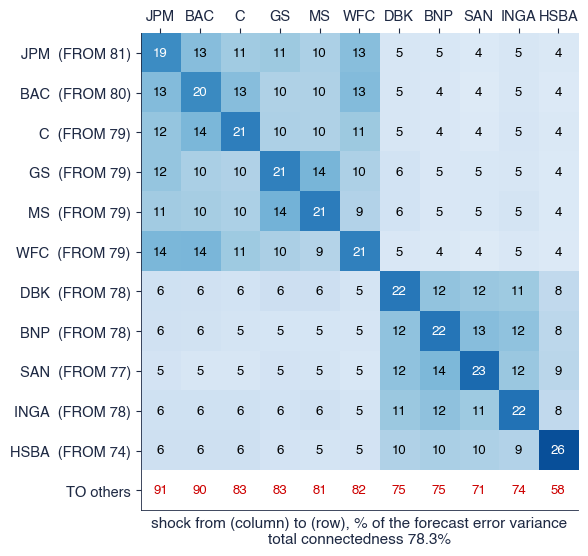

In [28]:
c, p, n = dy_static()
print('VAR order', p, 'days', n, 'total connectedness', round(c['total'], 1))
fig_dy_table(c, save=False)
pd.DataFrame({'TO': c['to'], 'FROM': c['from'], 'NET': c['net']}).round(1)

{'min': 60.68430364773201,
 'date_min': '2006-04-28',
 'max': 86.41684958773739,
 'date_max': '2020-03-17',
 'last': 77.15385971023794,
 'mean': 77.51636263091456,
 'y2017': 80.22071156836527,
 'y2008': 79.27839666363157}

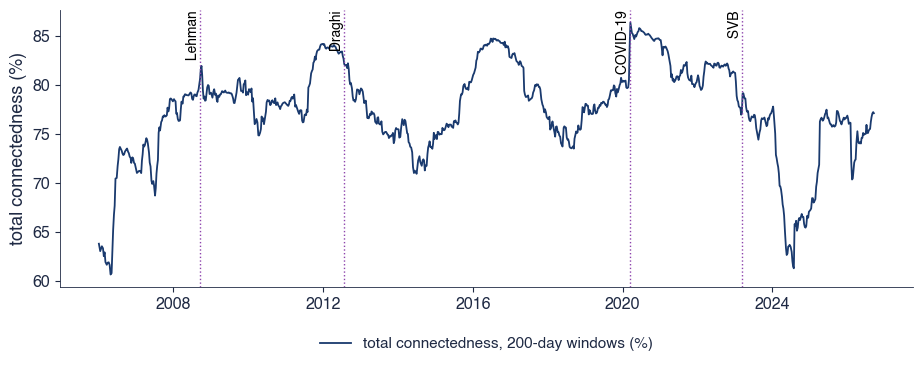

In [29]:
fig_dy_rolling(save=False)

## 7. AI for scientific discovery: is the systemic risk of the Romanian banks imported?

- Open question: does the euro-area banking sector raise the tail risk of TLV and BRD in stress periods?
- Starter result: Delta-CoVaR 1% of each Romanian bank conditional on the European bank portfolio.
- Check before trusting any answer, yours or an AI's: the level convention (CoVaR 1% is a positive loss), the direction of conditioning, Delta-CoVaR against the median, prices joined on common days, bootstrap intervals.

In [30]:
R = returns(REGIONS['EU'] + REGIONS['RO'], start='2010-01-01')
eu = bank_portfolio(R, REGIONS['EU'])
for k in REGIONS['RO']:
    c = covar(R[k], eu, 0.01)
    print(k, 'Delta-CoVaR 1% given the European banks:', round(c['dcovar'], 2), 'slope', round(c['b'], 2))

TLV Delta-CoVaR 1% given the European banks: 2.1 slope 0.34
BRD Delta-CoVaR 1% given the European banks: 2.07 slope 0.34
